In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Load the Dataset



In [26]:
df = pd.read_csv(r'C:\Users\mk929\Downloads\Advertising.csv')

In [27]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [28]:
df.shape

(200, 5)

In [29]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [30]:
df = df.drop('Unnamed: 0', axis = 1)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [31]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [32]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


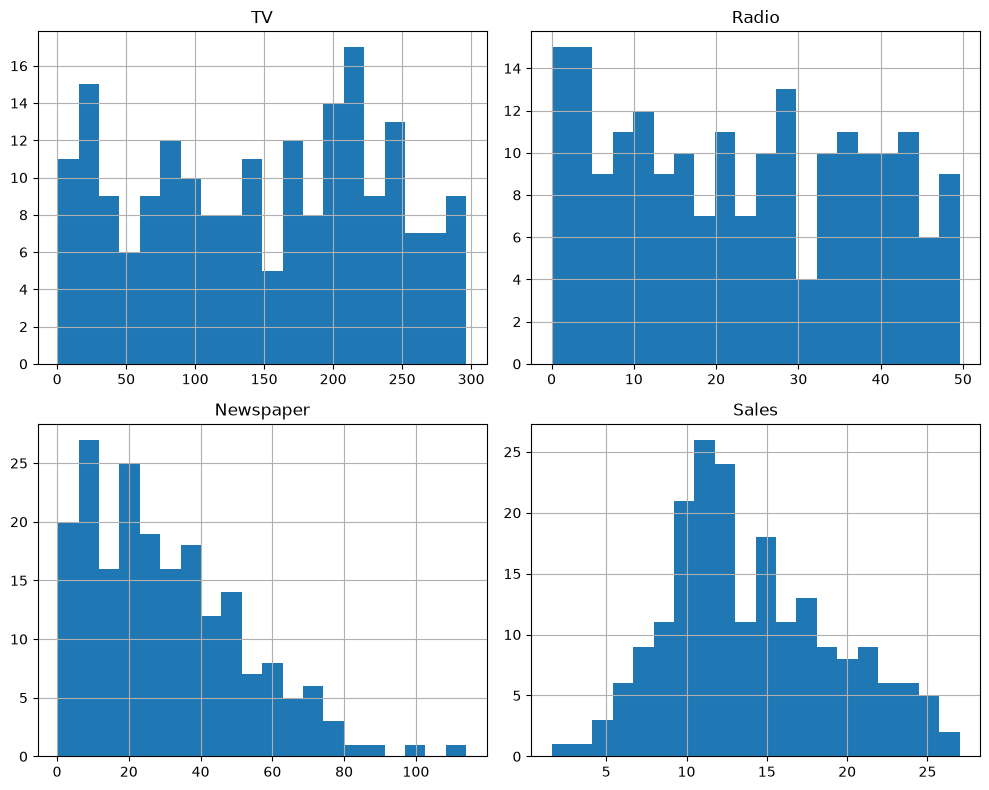

In [35]:
df.hist(figsize=(10,8),bins=20)
plt.tight_layout()
plt.show()

# Box Plot (Outlier Detection)

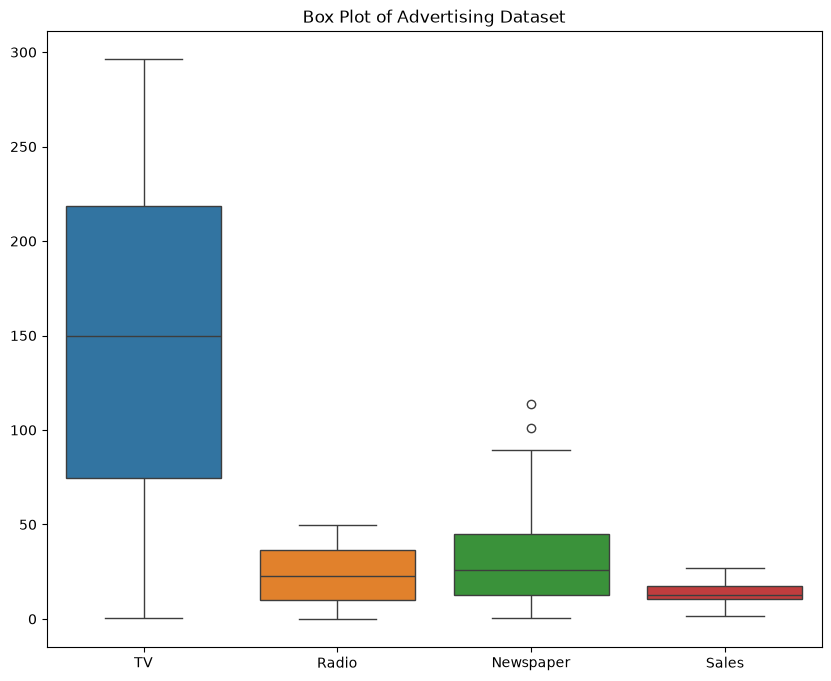

In [36]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df)
# Title
plt.title("Box Plot of Advertising Dataset")
plt.show()

# Scatter Plot (Relationship Between Advertising and Sales)

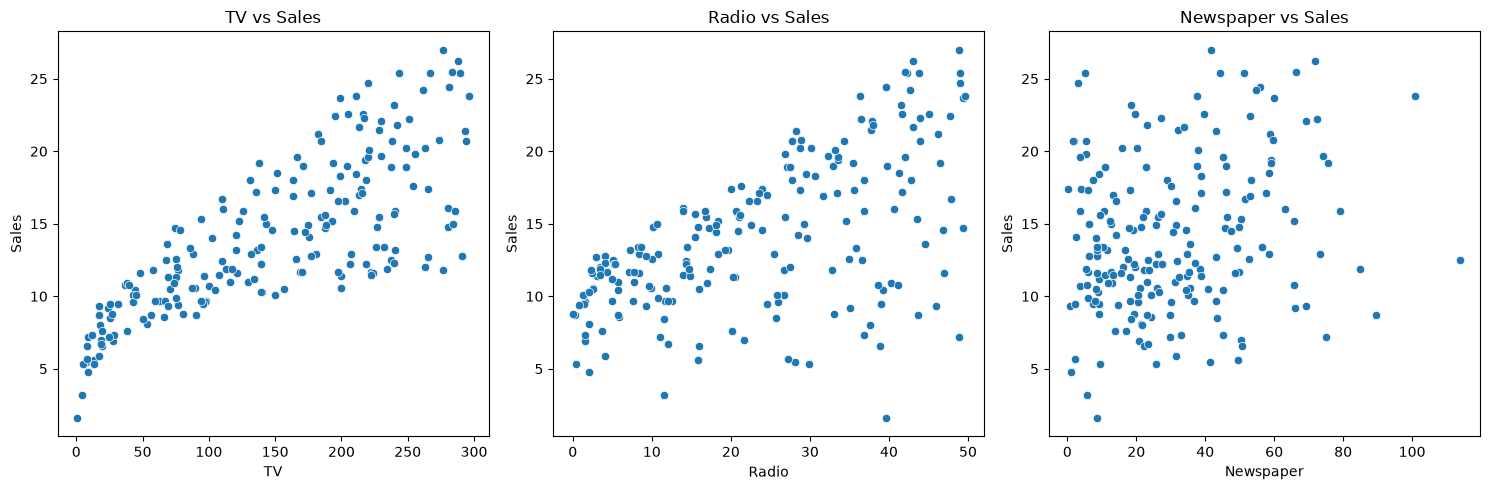

In [38]:
plt.figure(figsize=(15,5))

# TV vs Sales
plt.subplot(1,3,1)
sns.scatterplot(x=df["TV"], y=df["Sales"])
plt.title("TV vs Sales")

# Radio vs Sales
plt.subplot(1,3,2)
sns.scatterplot(x=df["Radio"], y=df["Sales"])
plt.title("Radio vs Sales")

# Newspaper vs Sales
plt.subplot(1,3,3)
sns.scatterplot(x=df["Newspaper"], y=df["Sales"])
plt.title("Newspaper vs Sales")

plt.tight_layout()
plt.show()

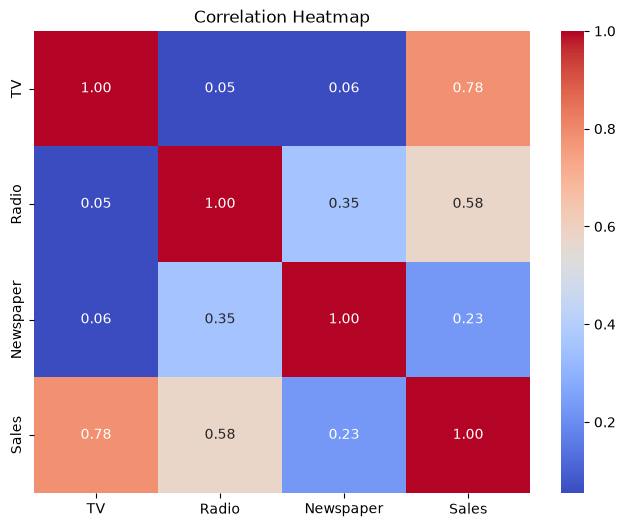

In [40]:
plt.figure(figsize=(8, 6))

# Calculate correlation matrix
corr = df.corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

# Title
plt.title("Correlation Heatmap")

# Display
plt.show()

In [41]:


# Features (Input)
X = df[["TV", "Radio", "Newspaper"]]

# Target (Output)
y = df["Sales"]

# Display
print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Features (X):


,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4



Target (y):


0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64

In [42]:
from sklearn.model_selection import train_test_split

# split the dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#check the shape
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (160, 3)
X_test: (40, 3)
y_train: (160,)
y_test: (40,)


# Train the Linear Regression Model

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)
print("Model trained successfully.")



Model trained successfully.


In [44]:
y_pred = model.predict(X_test)

# Display first 5 predictions
print("Predicted Sales:")
print(y_pred[:5])

Predicted Sales:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326]


In [46]:
# ==========================================
# Compare Actual vs Predicted
# ==========================================

comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(5)

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
